In [2]:
import numpy as np
print(np.__file__)
print(np.__version__)


c:\Users\Debabrata\anaconda3\envs\BRIGHT\Lib\site-packages\numpy\__init__.py
1.26.4


In [3]:
import os
import pandas as pd

# ==== 1. Set your root folder ====
ROOT = r"D:\rsna-pneumonia-detection-challenge"

print("Root folder:", ROOT)
print("=" * 80)

# ==== 2. Walk through folders and print structure ====
for root, dirs, files in os.walk(ROOT):
    level = root.replace(ROOT, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:10]:  # print first 10 only
        print(f"{subindent}{f}")
    if len(files) > 10:
        print(f"{subindent}... ({len(files)} files)")
print("=" * 80)


# ==== 3. Load available CSV files ====
csv_files = [f for f in os.listdir(ROOT) if f.endswith('.csv')]
print("Found CSV files:", csv_files)

csv_data = {}
for csv in csv_files:
    path = os.path.join(ROOT, csv)
    try:
        df = pd.read_csv(path)
        csv_data[csv] = df
        print(f"\nLoaded: {csv}  | Shape: {df.shape}")
        print(df.head())
    except Exception as e:
        print(f"Could not read {csv}: {e}")

print("=" * 80)


# ==== 4. Check basic dataset stats ====

if "stage_2_train_labels.csv" in csv_data:
    df = csv_data["stage_2_train_labels.csv"]

    print("\nColumn names:", list(df.columns))

    # Bounding boxes present?
    has_boxes = df[df["Target"] == 1]
    no_boxes = df[df["Target"] == 0]

    print("\nImage count:", df["patientId"].nunique())
    print("Pneumonia cases (Target=1):", len(has_boxes))
    print("Normal cases (Target=0):", len(no_boxes))

    # How many have multiple boxes?
    multi_boxes = has_boxes.groupby("patientId").size()
    print("Images with multiple bounding boxes:", (multi_boxes > 1).sum())

print("=" * 80)


# ==== 5. DICOM folder check ====
dicom_folders = [d for d in os.listdir(ROOT) if "image" in d.lower()]
print("Potential image folders:", dicom_folders)

for folder in dicom_folders:
    full = os.path.join(ROOT, folder)
    files = os.listdir(full)
    print(f"\nFolder: {folder}")
    print("Total DICOMs:", len(files))
    print("Sample files:", files[:5])


Root folder: D:\rsna-pneumonia-detection-challenge
rsna-pneumonia-detection-challenge/
    GCP Credits Request Link - RSNA.txt
    stage_2_detailed_class_info.csv
    stage_2_sample_submission.csv
    stage_2_train_labels.csv
    rsna_yolo/
        data.yaml
        images/
            train/
                0004cfab-14fd-4e49-80ba-63a80b6bddd6.png
                000924cf-0f8d-42bd-9158-1af53881a557.png
                000db696-cf54-4385-b10b-6b16fbb3f985.png
                000fe35a-2649-43d4-b027-e67796d412e0.png
                001031d9-f904-4a23-b3e5-2c088acd19c6.png
                0010f549-b242-4e94-87a8-57d79de215fc.png
                001916b8-3d30-4935-a5d1-8eaddb1646cd.png
                0022073f-cec8-42ec-ab5f-bc2314649235.png
                0022995a-45eb-4cfa-9a59-cd15f5196c64.png
                00313ee0-9eaa-42f4-b0ab-c148ed3241cd.png
                ... (21347 files)
            val/
                0025d2de-bd78-4d36-9f72-e15a5e22ca82.png
                00293de0-a53

In [4]:
# Cell 1: install (run if needed) and imports
# If you've already installed timm, torchvision, pydicom etc, you can skip installation lines.

# Uncomment to install if necessary
# !pip install timm==0.9.2 --quiet
# !pip install torch torchvision --quiet
# !pip install scikit-learn matplotlib pillow pandas --quiet

import os
import random
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [5]:
# Cell 2: dataset paths (adjust if needed)
ROOT = r"D:\rsna-pneumonia-detection-challenge"
YOLO_IMG_TRAIN = os.path.join(ROOT, "rsna_yolo", "images", "train")
YOLO_IMG_VAL   = os.path.join(ROOT, "rsna_yolo", "images", "val")
LABEL_CSV = os.path.join(ROOT, "stage_2_train_labels.csv")  # has patientId, x,y,width,height,Target

print("Train PNG folder:", YOLO_IMG_TRAIN)
print("Val PNG folder:", YOLO_IMG_VAL)
print("Label csv:", LABEL_CSV)

# quick sanity
print("Train PNG count:", len(os.listdir(YOLO_IMG_TRAIN)))
print("Val PNG count:", len(os.listdir(YOLO_IMG_VAL)))

# load label CSV
df_labels = pd.read_csv(LABEL_CSV)
df_labels = df_labels[["patientId", "Target"]].drop_duplicates(subset="patientId").set_index("patientId")
print("Unique images in CSV:", len(df_labels))
df_labels.head()


Train PNG folder: D:\rsna-pneumonia-detection-challenge\rsna_yolo\images\train
Val PNG folder: D:\rsna-pneumonia-detection-challenge\rsna_yolo\images\val
Label csv: D:\rsna-pneumonia-detection-challenge\stage_2_train_labels.csv
Train PNG count: 21347
Val PNG count: 5337
Unique images in CSV: 26684


,Target
patientId,
0004cfab-14fd-4e49-80ba-63a80b6bddd6,0
00313ee0-9eaa-42f4-b0ab-c148ed3241cd,0
00322d4d-1c29-4943-afc9-b6754be640eb,0
003d8fa0-6bf1-40ed-b54c-ac657f8495c5,0
00436515-870c-4b36-a041-de91049b9ab4,1


In [6]:
# Cell 3: helper to get label from filename (some files may be absent in CSV — treat as 0)
def get_label_from_patientid(pid: str):
    # pid expected without extension
    try:
        return int(df_labels.loc[pid, "Target"])
    except Exception:
        # if missing, assume 0 (no pneumonia)
        return 0

# quick test:
sample_p = os.listdir(YOLO_IMG_TRAIN)[0]
print(sample_p, "->", get_label_from_patientid(os.path.splitext(sample_p)[0]))


0004cfab-14fd-4e49-80ba-63a80b6bddd6.png -> 0


In [7]:
# Cell 4: PyTorch dataset for PNGs (uses patientId -> label mapping)
class RSNAWholePNG(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = Path(img_dir)
        self.files = sorted([p for p in self.img_dir.iterdir() if p.suffix.lower() in [".png", ".jpg", ".jpeg"]])
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        p = self.files[idx]
        pid = p.stem  # filename without extension
        label = get_label_from_patientid(pid)
        img = Image.open(p).convert("RGB")  # ensure 3 channels
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32), pid

# quick sanity
ds = RSNAWholePNG(YOLO_IMG_TRAIN, transform=T.ToTensor())
print("Sample length:", len(ds))
img, lbl, pid = ds[0]
print(img.shape, lbl, pid)


Sample length: 21347
torch.Size([3, 512, 512]) tensor(0.) 0004cfab-14fd-4e49-80ba-63a80b6bddd6


In [13]:
# Cell 5: transforms & dataloaders
IMG_SIZE = 224  # for EfficientNet-B2 you might pick 260 or 260; 224 is standard baseline
BATCH_SIZE = 32
NUM_WORKERS = 0

train_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

train_ds = RSNAWholePNG(YOLO_IMG_TRAIN, transform=train_transforms)
val_ds   = RSNAWholePNG(YOLO_IMG_VAL, transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Train batches:", len(train_loader), "Val batches:", len(val_loader))


Train batches: 668 Val batches: 167


In [9]:
# Cell 6: model builder functions
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def build_model(name="efficientnet_b2", pretrained=True):
    # create binary classifier with timm backbone
    model = timm.create_model(name, pretrained=pretrained, num_classes=0, global_pool='avg')  # feature extractor
    in_features = model.num_features
    head = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 1)  # single logit
    )
    model = nn.Sequential(model, nn.Flatten(), head)  # wrap features + head
    return model.to(device)

# quick build test
m1 = build_model("efficientnet_b2")
m2 = build_model("convnext_tiny")
print("EffNet-B2 built. ConvNeXt-Tiny built.")


Device: cuda
EffNet-B2 built. ConvNeXt-Tiny built.


In [11]:
# Cell 7: training + validation utilities
criterion = nn.BCEWithLogitsLoss()

def train_one_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    running_loss = 0.0
    for imgs, labels, _ in tqdm(loader, desc="Train batches", leave=False):
        imgs = imgs.to(device)
        labels = labels.to(device).unsqueeze(1)  # shape (B,1)
        logits = model(imgs)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(loader.dataset)

@torch.no_grad()
def validate(model, loader):
    model.eval()
    preds = []
    probs = []
    targets = []
    pids = []
    running_loss = 0.0
    for imgs, labels, ids in tqdm(loader, desc="Val batches", leave=False):
        imgs = imgs.to(device)
        labels = labels.to(device).unsqueeze(1)
        logits = model(imgs)
        loss = criterion(logits, labels)
        running_loss += loss.item() * imgs.size(0)
        prob = torch.sigmoid(logits).cpu().numpy().ravel().tolist()
        pred = (np.array(prob) >= 0.5).astype(int).tolist()
        preds.extend(pred)
        probs.extend(prob)
        targets.extend(labels.cpu().numpy().ravel().tolist())
        pids.extend(ids)
    return running_loss / len(loader.dataset), np.array(preds), np.array(probs), np.array(targets), pids


In [11]:
# Cell 8: Full training loop for one model (EffNet-B2). Adjust EPOCHS as needed.
EPOCHS = 8
LR = 3e-4

model_name = "efficientnet_b2"
model = build_model(model_name, pretrained=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
# optional scheduler (commented if not desired)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scheduler = None

best_auc = 0.0
best_path = f"best_{model_name}.pth"

for epoch in range(1, EPOCHS+1):
    print(f"\nEpoch {epoch}/{EPOCHS} -----")
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler)
    val_loss, val_preds, val_probs, val_targets, val_pids = validate(model, val_loader)
    try:
        val_auc = roc_auc_score(val_targets, val_probs)
    except ValueError:
        val_auc = 0.0
    prec, rec, f1, _ = precision_recall_fscore_support(val_targets, val_preds, average='binary', zero_division=0)
    print(f"Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Val AUC: {val_auc:.4f} | Val F1: {f1:.4f}")
    # checkpoint best by AUC
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "val_auc": val_auc
        }, best_path)
        print("Saved best model:", best_path)
print("Training finished. Best AUC:", best_auc)



Epoch 1/8 -----


Train loss: 0.3840 | Val loss: 0.3509 | Val AUC: 0.8824 | Val F1: 0.6175
Saved best model: best_efficientnet_b2.pth

Epoch 2/8 -----


Train loss: 0.3526 | Val loss: 0.3417 | Val AUC: 0.8879 | Val F1: 0.6232
Saved best model: best_efficientnet_b2.pth

Epoch 3/8 -----


Train loss: 0.3345 | Val loss: 0.3510 | Val AUC: 0.8869 | Val F1: 0.6348

Epoch 4/8 -----


Train loss: 0.3235 | Val loss: 0.3521 | Val AUC: 0.8844 | Val F1: 0.5969

Epoch 5/8 -----


Train loss: 0.3070 | Val loss: 0.3509 | Val AUC: 0.8811 | Val F1: 0.5710

Epoch 6/8 -----


Train loss: 0.2894 | Val loss: 0.3635 | Val AUC: 0.8769 | Val F1: 0.6191

Epoch 7/8 -----


Train loss: 0.2678 | Val loss: 0.4059 | Val AUC: 0.8597 | Val F1: 0.5358

Epoch 8/8 -----


Train loss: 0.2389 | Val loss: 0.3992 | Val AUC: 0.8715 | Val F1: 0.6152
Training finished. Best AUC: 0.8879219574340647


Classification Report:

              precision    recall  f1-score   support

           0     0.8753    0.9314    0.9025      4108
           1     0.7081    0.5566    0.6232      1229

    accuracy                         0.8450      5337
   macro avg     0.7917    0.7440    0.7628      5337
weighted avg     0.8368    0.8450    0.8382      5337



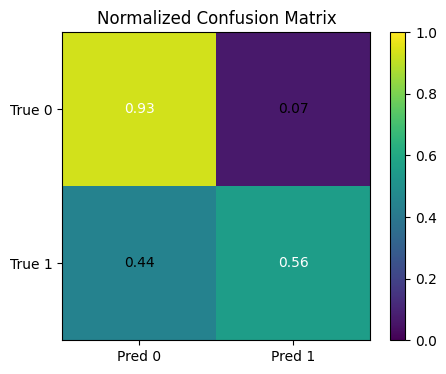

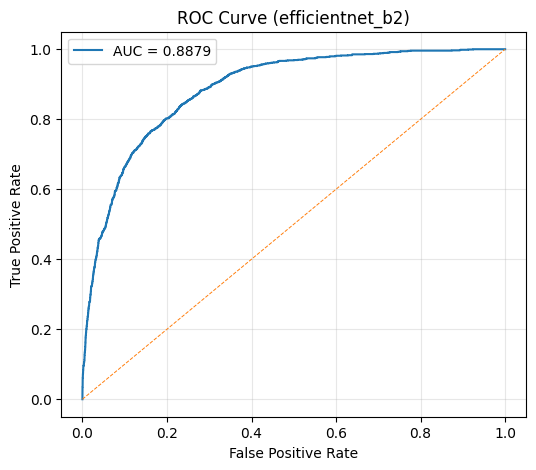

In [13]:
# Cell 9: Load best model and evaluate to produce metrics and plots
ckpt = torch.load(f"best_{model_name}.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# get full val predictions
_, val_preds, val_probs, val_targets, val_pids = validate(model, val_loader)

# classification report
y_true = val_targets.astype(int)
y_pred = val_preds.astype(int)
print("Classification Report:\n")
print(classification_report(y_true, y_pred, digits=4))

# confusion matrix (normalized)
cm = confusion_matrix(y_true, y_pred, normalize='true')  # normalize over true labels (recall per-class)
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, vmin=0, vmax=1)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Pred 0","Pred 1"])
ax.set_yticklabels(["True 0","True 1"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center", color="white" if cm[i,j]>0.5 else "black")
plt.title("Normalized Confusion Matrix")
plt.colorbar(im)
plt.show()

# ROC curve + AUC
fpr, tpr, th = roc_curve(y_true, val_probs)
auc_score = roc_auc_score(y_true, val_probs)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1],[0,1], '--', linewidth=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({model_name})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [15]:
# Cell 10: Save final model (already saved best by AUC). Save predictions to CSV.
final_weights = f"{model_name}_final.pth"
torch.save(model.state_dict(), final_weights)
print("Saved final state dict:", final_weights)

# save val predictions
out_df = pd.DataFrame({
    "patientId": val_pids,
    "y_true": y_true,
    "y_pred": y_pred,
    "y_prob": val_probs
})
out_df.to_csv(f"{model_name}_val_predictions.csv", index=False)
print("Saved val predictions CSV.")


Saved final state dict: efficientnet_b2_final.pth
Saved val predictions CSV.


In [16]:
# ==== Cell 11: Train ConvNeXt-Tiny Properly ====

EPOCHS = 8
LR = 3e-4

# ---- Build proper binary classifier head ----
def build_convnext_binary():
    model = timm.create_model(
        "convnext_tiny",
        pretrained=True,
        num_classes=1   # IMPORTANT: single logit for BCEWithLogitsLoss
    )
    return model.to(device)

model = build_convnext_binary()

# ---- Compute pos_weight for imbalance ----
pos = (df_labels["Target"] == 1).sum()
neg = (df_labels["Target"] == 0).sum()
pos_weight = torch.tensor([neg / pos], device=device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)

best_auc = 0.0
best_path = "best_convnext_tiny.pth"

print(f"Using pos_weight = {neg/pos:.4f}")

for epoch in range(1, EPOCHS + 1):

    print(f"\nEpoch {epoch}/{EPOCHS} -----")

    # ---- Train ----
    model.train()
    running_loss = 0

    for imgs, labs, _ in train_loader:
        imgs = imgs.to(device)
        labs = labs.float().view(-1, 1).to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labs)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # ---- Validate ----
    model.eval()
    all_probs = []
    all_preds = []
    all_targets = []
    all_pids = []
    val_running_loss = 0

    with torch.no_grad():
        for imgs, labs, pids in val_loader:
            imgs = imgs.to(device)
            labs_f = labs.float().view(-1, 1).to(device)

            logits = model(imgs)
            loss = criterion(logits, labs_f)
            val_running_loss += loss.item() * imgs.size(0)

            probs = torch.sigmoid(logits).squeeze(-1).cpu().numpy()
            preds = (probs >= 0.5).astype(int)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_targets.extend(labs.cpu().numpy().astype(int))
            all_pids.extend(pids)

    val_loss = val_running_loss / len(val_loader.dataset)

    # ---- Metrics ----
    try:
        val_auc = roc_auc_score(all_targets, all_probs)
    except:
        val_auc = 0.0
    
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average='binary', zero_division=0
    )

    print(f"Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | "
          f"Val AUC: {val_auc:.4f} | Val F1: {f1:.4f}")

    # Additional diagnostic: show highest probs
    print("Top probs this epoch:", sorted(all_probs)[-5:])

    # ---- Save best model ----
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "val_auc": val_auc,
            },
            best_path
        )
        print(f"Saved best model: {best_path}")

print("ConvNeXt training finished. Best AUC:", best_auc)


Using pos_weight = 3.4385

Epoch 1/8 -----
Train loss: 1.1020 | Val loss: 1.0899 | Val AUC: 0.6501 | Val F1: 0.0000
Top probs this epoch: [0.45761535, 0.45762268, 0.45763564, 0.45764595, 0.45766637]
Saved best model: best_convnext_tiny.pth

Epoch 2/8 -----
Train loss: 0.9993 | Val loss: 0.8821 | Val AUC: 0.7812 | Val F1: 0.5375
Top probs this epoch: [0.8921292, 0.89240205, 0.89275944, 0.89675856, 0.90050524]
Saved best model: best_convnext_tiny.pth

Epoch 3/8 -----
Train loss: 0.8955 | Val loss: 0.9582 | Val AUC: 0.7744 | Val F1: 0.4927
Top probs this epoch: [0.7557218, 0.7571685, 0.75829995, 0.7653892, 0.76789284]

Epoch 4/8 -----
Train loss: 0.8760 | Val loss: 0.8856 | Val AUC: 0.7989 | Val F1: 0.5193
Top probs this epoch: [0.8825077, 0.8833394, 0.8844851, 0.88612515, 0.8946887]
Saved best model: best_convnext_tiny.pth

Epoch 5/8 -----
Train loss: 0.8537 | Val loss: 0.8584 | Val AUC: 0.8123 | Val F1: 0.5760
Top probs this epoch: [0.87518024, 0.8759181, 0.8767028, 0.88108957, 0.881666

Loaded best model from epoch: 8
Best AUC in training: 0.8326471874522157

Best threshold for F1: 0.55 | Best F1: 0.5963

Classification Report (threshold optimized):

              precision    recall  f1-score   support

           0     0.9098    0.7760    0.8376      4108
           1     0.4981    0.7429    0.5963      1229

    accuracy                         0.7684      5337
   macro avg     0.7040    0.7595    0.7170      5337
weighted avg     0.8150    0.7684    0.7821      5337



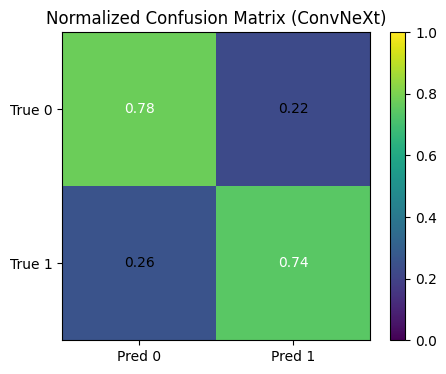

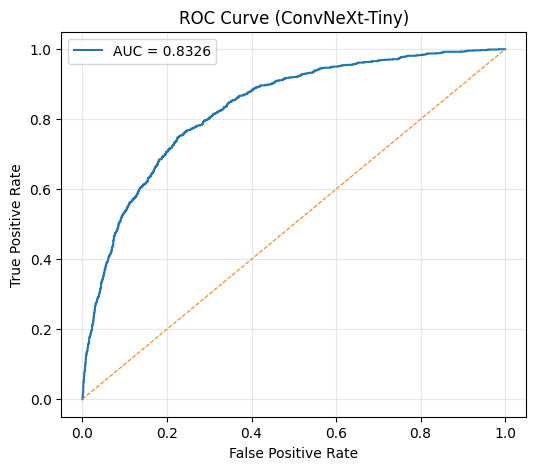

Saved prediction CSV: convnext_tiny_val_predictions.csv


In [17]:
# ==== Cell 12: Evaluate ConvNeXt-Tiny Properly ====

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_fscore_support, f1_score
)
import matplotlib.pyplot as plt

# ---- Load best model checkpoint ----
ckpt = torch.load("best_convnext_tiny.pth", map_location=device)

model = timm.create_model(
    "convnext_tiny",
    pretrained=False,
    num_classes=1
)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device)
model.eval()

print("Loaded best model from epoch:", ckpt["epoch"])
print("Best AUC in training:", ckpt["val_auc"])

# ---- Inference on VAL ----
all_probs, all_preds, all_targets, all_pids = [], [], [], []

with torch.no_grad():
    for imgs, labs, pids in val_loader:
        imgs = imgs.to(device)
        logits = model(imgs)

        probs = torch.sigmoid(logits).squeeze(-1).cpu().numpy()
        preds = (probs >= 0.5).astype(int)

        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_targets.extend(labs.numpy().astype(int).tolist())
        all_pids.extend(pids)

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# ---- Find Best Threshold for F1 ----
thresholds = np.linspace(0.05, 0.95, 19)
best_f1, best_t = 0, 0.5

for t in thresholds:
    pred_t = (all_probs >= t).astype(int)
    f1 = f1_score(all_targets, pred_t, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nBest threshold for F1: {best_t:.2f} | Best F1: {best_f1:.4f}")

# ---- Metrics @ optimal threshold ----
final_preds = (all_probs >= best_t).astype(int)

auc = roc_auc_score(all_targets, all_probs)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_targets, final_preds, average='binary', zero_division=0
)

print("\nClassification Report (threshold optimized):\n")
print(classification_report(all_targets, final_preds, digits=4))

# ---- Normalized Confusion Matrix ----
cm = confusion_matrix(all_targets, final_preds, normalize='true')
plt.figure(figsize=(5,4))
plt.imshow(cm, vmin=0, vmax=1)
plt.title("Normalized Confusion Matrix (ConvNeXt)")
plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["True 0", "True 1"])

for i in range(2):
    for j in range(2):
        val = f"{cm[i,j]:.2f}"
        color = "white" if cm[i,j] > 0.5 else "black"
        plt.text(j, i, val, ha="center", va="center", color=color)

plt.colorbar()
plt.show()

# ---- ROC Curve ----
fpr, tpr, th = roc_curve(all_targets, all_probs)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1], linestyle="--", linewidth=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (ConvNeXt-Tiny)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ---- Save predictions ----
out_df = pd.DataFrame({
    "patientId": all_pids,
    "true": all_targets,
    "prob": all_probs,
    "pred_default": all_preds,         # threshold 0.5
    "pred_bestT": final_preds          # threshold best_t
})

out_df.to_csv("convnext_tiny_val_predictions.csv", index=False)
print("Saved prediction CSV: convnext_tiny_val_predictions.csv")


In [16]:
from collections import Counter
import os
import pandas as pd

ROOT = r"D:\rsna-pneumonia-detection-challenge"
YOLO_IMG_TRAIN = os.path.join(ROOT, "rsna_yolo", "images", "train")
YOLO_IMG_VAL   = os.path.join(ROOT, "rsna_yolo", "images", "val")
LABEL_CSV = os.path.join(ROOT, "stage_2_train_labels.csv")

df_labels = pd.read_csv(LABEL_CSV)
df_labels = df_labels[["patientId", "Target"]].drop_duplicates("patientId").set_index("patientId")

def get_label(pid):
    return int(df_labels.loc[pid, "Target"]) if pid in df_labels.index else 0

def count_labels(img_dir):
    counts = Counter()
    for f in os.listdir(img_dir):
        if f.endswith(".png"):
            pid = os.path.splitext(f)[0]
            lbl = get_label(pid)
            counts[lbl] += 1
    return counts

train_counts = count_labels(YOLO_IMG_TRAIN)
val_counts = count_labels(YOLO_IMG_VAL)

print("Train counts:", train_counts)
print("Val counts:", val_counts)


Train counts: Counter({0: 16564, 1: 4783})
Val counts: Counter({0: 4108, 1: 1229})
